## Set root

In [13]:
import pyrootutils
from pathlib import Path

filepath = Path.cwd()
root = pyrootutils.setup_root(filepath, indicator=".project-root", pythonpath=True)
root_use_case = root / "use_case"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load data handler and predictions
Then the predictions are loaded into the data handler. These will be packaged together with the other data samples.

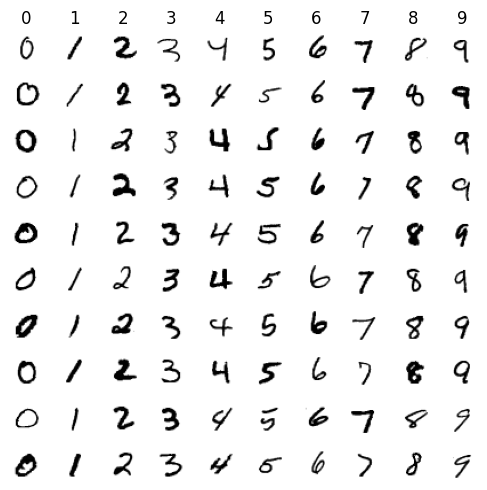

In [14]:
from use_case.src.data.keras_mnist_datahandler import KerasMNISTDataHandler

data_handler = KerasMNISTDataHandler(data_dir=root_use_case / "data/mnist").from_joblib()

data_handler.plot_samples(n_samples_per_class=10)

# Load prediction model
You can choose between an MLP and a CNN.

In [15]:
from keras.models import load_model

model = load_model(root_use_case / "model/mlp")

print(model.summary())

Model: "mlp"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               200960    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 10)                1290      
                                                                 
Total params: 235146 (918.54 KB)
Trainable params: 235146 (918.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


## Instantiate the model handler.
The model handler acts as a translator between the model and safetycage, translating the syntax of the model to something standardize that the safetycage can use, for all models.

In [16]:
from use_case.src.model.keras_modelhandler import ModelHandlerKeras

model_handler = ModelHandlerKeras(
    model=model, selected_layers=["dense_2"], use_onehot_encoder=True
)

## Instantiate a safetycage

In [17]:
# from components.spardacus import SPARDACUS
from safetycage_testing.methods.spardacus import SPARDACUS

safetycage = SPARDACUS(model_handler, data_handler, s_statistic_source = "correctly", test_type_between_layer = "cauchy", cauchy_weights_per_layer = [])

## Train the safetycage

In [18]:
inputs_train, labels_train = data_handler.data_train

predictions_train = model_handler._get_predictions(inputs_train)

# Train the safety cage on training data
safetycage.train_cage(x=inputs_train, y=labels_train, y_pred=predictions_train)

1500/1500 [==============================] - 3s 2ms/step


100%|██████████| 10/10 [00:14<00:00,  1.43s/it]


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy = accuracy_score(labels_train, predictions_train)
precision = precision_score(labels_train, predictions_train, average="weighted")
recall = recall_score(labels_train, predictions_train, average="weighted")

print("Performance on training data:")
print(f"Accuracy: {accuracy * 100:.4f} %")
print(f"Precision: {precision * 100:.4f} %")
print(f"Recall: {recall * 100:.4f} %")

Performance on training data:
Accuracy: 99.3563 %
Precision: 99.3622 %
Recall: 99.3563 %


## Safetycage predicts on validation data
Safetycage predicts whether samples have been misclassified by classifier. The type of statistic will vary depending on the safetycage method, but will say something about how likely it is a given sample has been misclassified.

In [20]:
import numpy as np

inputs_val, labels_val = data_handler.data_val

predictions_val = model_handler._get_predictions(inputs_val)
incorrect_predictions_val = ~(
    np.argmax(predictions_val, axis=1) == np.argmax(labels_val, axis=1)
)

max_probs_val = safetycage.predict(
    x=inputs_val,
    y=predictions_val,
)

375/375 [==============================] - 1s 1ms/step


## Find threshold that maximizes a performance metric
Use the statistics from the validation data produced by the safetycage, to find a theshold that will maximize a metric, when compared to the ground truth (correct or incorrect classification)

In [21]:
from safetycage_testing.utils.evaluate import find_best_threshold, MCC

# Find optimal alpha for specified max metric based on the validation data
optimisation_result = find_best_threshold(
    y_probs=max_probs_val,
    y_true=incorrect_predictions_val,
    metric_fn=MCC,
    greater_is_better=True,
    #leq=False
)

threshold_val = optimisation_result["alpha_opt"]
metric_val = optimisation_result["metric_max"]

print("\nOptimal threshold and performance metric based on validation data:")
print(f"Threshold = {threshold_val:.4f}")
print(f"{MCC.__name__} = {metric_val:.4f}")

safetycage.alpha = threshold_val
safetycage.threshold_metric_val = metric_val


Optimal threshold and performance metric based on validation data:
Threshold = 0.0195
MCC = 0.5036


## Test with optimal threshold, the performance on the test data partition.
Finally we test the safetycage with the inferred threshold parameter, on a hold out test data set. The flags are the predicitons made by the safetycage.

In [22]:
inputs_test, labels_test = data_handler.data_test

prediction_test = model_handler._get_predictions(inputs_test)
incorrect_prediction_test = ~(
    np.argmax(prediction_test, axis=1) == np.argmax(labels_test, axis=1)
)

max_probs_test = safetycage.predict(
    x=inputs_test,
    y=prediction_test,
)

flags_test = safetycage.flag(max_probs_test)

313/313 [==============================] - 1s 2ms/step


# Calculate metrics of the predictions on the test data set.
Compute a set of metrics that will inform us of the safetycages abillity to flag misclassification made by a certain model on a certain dataset.

In [23]:
from safetycage_testing.utils.evaluate import (
    calculate_confusion_rates,
    calculate_metrics,
    calculate_auroc,
)

# Calculate confusion rates and metrics based on test data
confusion_rates_test = calculate_confusion_rates(
    y=incorrect_prediction_test,
    y_pred=flags_test,
)

# Calculate AUROC based on test data
auroc_test = calculate_auroc(
    safetycage=safetycage,
    y_true=incorrect_prediction_test,
    y_scores=max_probs_test,  # Assuming the first column contains the scores
)

# Calculate metrics based on test data
metrics_test = calculate_metrics(y=incorrect_prediction_test, y_pred=flags_test)

# Add confusion rates and AUROC to metrics dictionary
metrics_test.update(confusion_rates_test)
metrics_test.update({"AUROC": auroc_test})

for key, value in metrics_test.items():
    print(f"{key}: {value:.4f}")

Precision: 0.3812
Recall: 0.6109
Specificity: 0.9757
NPV: 0.9903
MCC: 0.4668
TP: 146.0000
TN: 9524.0000
FP: 237.0000
FN: 93.0000
AUROC: 0.9528


## Plots
Further we plot a number of figures showing further the performance of safetycage. These plots are the confusion matrix, the alpha-metric curve (how the  metric varies with the threshold), and the reciever-operator curve.

In [24]:
from safetycage_testing.utils.evaluate import calculate_roc_curve

from safetycage_testing.utils.plot_functions import (
    plot_alpha_metric_curve,
    plot_confusion_matrix,
    plot_roc_curve,
)

best_metric_dict = find_best_threshold(
    y_probs=max_probs_test,
    y_true=incorrect_prediction_test,
    metric_fn=MCC,
    greater_is_better=True,
    #leq=False
)

# plots
plot_alpha_metric_curve(
    **best_metric_dict,
    thresholds=optimisation_result["alphas"],
    scores=optimisation_result["metric_values"],
    output_path="./plots",
    alpha_val=safetycage.alpha,
    metric_val=safetycage.threshold_metric_val,
    val_label_offset=(0.0, 0.10) # the validation label tends to cover the data
)

plot_confusion_matrix(
    y_true=incorrect_prediction_test,
    y_pred=flags_test,
    normalize="true",
    output_path="./plots",
)

roc = calculate_roc_curve(
    safetycage=safetycage,
    y_true=incorrect_prediction_test,
    statistics=max_probs_test,
    num_thresholds=1e4,
)

plot_roc_curve(
    **roc,
    output_path="./plots",
)